# **03 LangGraph 기본 사용법 - 메시지 상태 업데이트**

### 학습 내용
1. LangGraph의 State 개념 이해
2. 메시지 기반 상태 업데이트
3. add_messages 리듀서 활용
4. invoke/stream/astream 비교 및 사용법
5. 스트림 모드별 차이점 이해

## 1. 환경 설정

In [1]:
import os
from dotenv import load_dotenv

load_dotenv()

if os.environ.get("OPENAI_API_KEY"):
    print("API Key가 설정되었습니다.")

API Key가 설정되었습니다.


## 2. 챗봇 메시지 상태 관리


In [2]:
from langchain_core.messages import AnyMessage, HumanMessage, AIMessage
from typing_extensions import TypedDict

# State 정의
class State(TypedDict):
    messages: list[AnyMessage]
    extra_field: int

In [3]:
# 노드 정의 - 메시지를 수동으로 누적
def node(state: State):
    messages = state["messages"]
    new_message = AIMessage("안녕하세요! 무엇을 도와드릴까요?")

    return {"messages": messages + [new_message], "extra_field": 10}

In [4]:
from langgraph.graph import StateGraph

# 그래프 빌더 생성
graph_builder = StateGraph(State)
graph_builder.add_node("node", node)
graph_builder.set_entry_point("node")  # 시작 노드 지정
graph = graph_builder.compile()

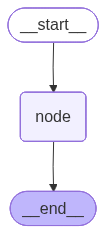

In [5]:
# 그래프 시각화
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception as e:
    print(e)

In [6]:
# 그래프 실행
result = graph.invoke({"messages": [HumanMessage("안녕")]})
print("\n실행 결과:")
print(result)


실행 결과:
{'messages': [HumanMessage(content='안녕', additional_kwargs={}, response_metadata={}), AIMessage(content='안녕하세요! 무엇을 도와드릴까요?', additional_kwargs={}, response_metadata={}, tool_calls=[], invalid_tool_calls=[])], 'extra_field': 10}


In [7]:
for msg in result["messages"]:
    msg.pretty_print()

================================ Human Message =================================

안녕
================================== Ai Message ==================================

안녕하세요! 무엇을 도와드릴까요?


## 3. add_messages 리듀서로 자동 누적

`add_messages`는 메시지를 자동으로 누적하는 **리듀서(reducer)** 함수입니다.

https://reference.langchain.com/python/langgraph/graph/message/add_messages


- 메시지 자동 병합
- 중복 메시지 ID 처리
- 코드 간소화
- 메시지 수정 및 삭제 지원

### 3-1. add_messages 기본 사용법

In [8]:
from langchain_core.messages import AIMessage, HumanMessage
from langgraph.graph.message import add_messages

msgs1 = [HumanMessage(content="Hello", id="1")]
msgs2 = [AIMessage(content="Hi there!", id="2")]
add_messages(msgs1, msgs2)

[HumanMessage(content='Hello', additional_kwargs={}, response_metadata={}, id='1'),
 AIMessage(content='Hi there!', additional_kwargs={}, response_metadata={}, id='2', tool_calls=[], invalid_tool_calls=[])]

In [9]:
# 동일 ID로 메시지 업데이트
msgs1 = [HumanMessage(content="첫 번째 메시지", id="1")]
msgs2 = [HumanMessage(content="수정된 메시지", id="1")]  # 동일 ID

result = add_messages(msgs1, msgs2)

print("\nID가 같은 경우 (메시지 수정):")
for msg in result:
    print(f"{type(msg).__name__} (id={msg.id}): {msg.content}")


ID가 같은 경우 (메시지 수정):
HumanMessage (id=1): 수정된 메시지


### 3-2. add_messages 를 리듀서로 사용하기

In [16]:
from typing_extensions import Annotated
from langgraph.graph.message import add_messages

# State 정의 - Annotated로 add_messages 리듀서 지정
class State(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]
    extra_field: int

In [17]:
def node(state: State):
    new_message = AIMessage("안녕하세요! 무엇을 도와드릴까요?")

    # 새 메시지만 반환 (add_messages가 자동으로 누적)
    return {"messages": new_message, "extra_field": 10}

In [18]:
graph_builder = StateGraph(State)
graph_builder.add_node("node", node)
graph_builder.set_entry_point("node")
graph = graph_builder.compile()

In [19]:
# 그래프 실행
input_message = {"role": "user", "content": "안녕하세요."}
result = graph.invoke({"messages": [input_message]})
print(result)
print("\n메시지 출력:")
for message in result["messages"]:
    message.pretty_print()

{'messages': [HumanMessage(content='안녕하세요.', additional_kwargs={}, response_metadata={}, id='03616079-1c7c-458a-b555-d2e213c55806'), AIMessage(content='안녕하세요! 무엇을 도와드릴까요?', additional_kwargs={}, response_metadata={}, id='9b71be76-0540-4ce1-ab4f-695b4752951e', tool_calls=[], invalid_tool_calls=[])], 'extra_field': 10}

메시지 출력:
================================ Human Message =================================

안녕하세요.
================================== Ai Message ==================================

안녕하세요! 무엇을 도와드릴까요?


In [20]:
# 상태 확인
print("\n전체 상태:")
print(f"extra_field: {result['extra_field']}")
print(f"메시지 개수: {len(result['messages'])}")


전체 상태:
extra_field: 10
메시지 개수: 2


## 4. LLM 연결하여 대화형 챗봇 그래프 만들기

In [21]:
from typing_extensions import Annotated
from langgraph.graph.message import add_messages
from langgraph.graph import StateGraph
from langchain.chat_models import init_chat_model

llm = init_chat_model(
    "gpt-4o-mini"
)

# State 정의
class State(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]

# 챗봇 노드
def chatbot(state: State):
    response = llm.invoke(state["messages"])
    return {"messages": response} # AIMessage 객체

# 그래프 구성
graph_builder = StateGraph(State)
graph_builder.add_node("chatbot", chatbot)
graph_builder.set_entry_point("chatbot")
graph = graph_builder.compile()

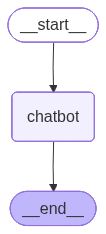

In [22]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception as e:
    print(e)

## 6. invoke - 일반 호출

In [23]:
# invoke - 동기 방식
user_message = HumanMessage("Python의 장점을 3가지만 알려주세요.")
result = graph.invoke({"messages": [user_message]})

print("\n[invoke 결과]")
for msg in result["messages"]:
    msg.pretty_print()


[invoke 결과]
================================ Human Message =================================

Python의 장점을 3가지만 알려주세요.
================================== Ai Message ==================================

Python의 주요 장점은 다음과 같습니다:

1. **간결하고 읽기 쉬운 문법**: Python은 간단하고 명확한 문법으로 설계되어 있어, 코드 작성과 유지보수가 용이합니다. 이는 개발자가 코드를 쉽게 이해하고 협업할 수 있도록 도와줍니다.

2. **풍부한 라이브러리와 프레임워크**: Python은 다양한 분야에서 사용할 수 있는 방대한 라이브러리와 프레임워크를 제공합니다. 예를 들어, 데이터 분석을 위한 Pandas, 머신러닝을 위한 TensorFlow 및 scikit-learn, 웹 개발을 위한 Django 및 Flask 등이 있습니다. 이를 통해 개발자는 복잡한 작업을 더 간편하게 수행할 수 있습니다.

3. **활발한 커뮤니티와 지원**: Python은 전 세계에 많은 사용자와 개발자가 있는 대규모 커뮤니티를 가지고 있습니다. 이는 문제 해결 시 도움을 받을 수 있는 자료와 리소스가 풍부하며, 다양한 튜토리얼, 문서 및 포럼이 활성화되어 있다는 것을 의미합니다. 

이러한 장점들 덕분에 Python은 웹 개발, 데이터 과학, 인공지능 등 다양한 분야에서 널리 사용되고 있습니다.


In [24]:
result

{'messages': [HumanMessage(content='Python의 장점을 3가지만 알려주세요.', additional_kwargs={}, response_metadata={}, id='1be3ddb4-143d-4f84-b570-f786d5b8a55c'),
  AIMessage(content='Python의 주요 장점은 다음과 같습니다:\n\n1. **간결하고 읽기 쉬운 문법**: Python은 간단하고 명확한 문법으로 설계되어 있어, 코드 작성과 유지보수가 용이합니다. 이는 개발자가 코드를 쉽게 이해하고 협업할 수 있도록 도와줍니다.\n\n2. **풍부한 라이브러리와 프레임워크**: Python은 다양한 분야에서 사용할 수 있는 방대한 라이브러리와 프레임워크를 제공합니다. 예를 들어, 데이터 분석을 위한 Pandas, 머신러닝을 위한 TensorFlow 및 scikit-learn, 웹 개발을 위한 Django 및 Flask 등이 있습니다. 이를 통해 개발자는 복잡한 작업을 더 간편하게 수행할 수 있습니다.\n\n3. **활발한 커뮤니티와 지원**: Python은 전 세계에 많은 사용자와 개발자가 있는 대규모 커뮤니티를 가지고 있습니다. 이는 문제 해결 시 도움을 받을 수 있는 자료와 리소스가 풍부하며, 다양한 튜토리얼, 문서 및 포럼이 활성화되어 있다는 것을 의미합니다. \n\n이러한 장점들 덕분에 Python은 웹 개발, 데이터 과학, 인공지능 등 다양한 분야에서 널리 사용되고 있습니다.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 267, 'prompt_tokens': 18, 'total_tokens': 285, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_pre

## 7. stream - 스트리밍 호출

`stream`은 중간 결과를 실시간으로 반환합니다.

### 스트림 모드

- **values**: 각 단계의 전체 상태 출력
- **updates**: 각 단계의 업데이트만 출력 (기본값)
- **messages**: 메시지와 메타데이터 출력

In [25]:
# stream_mode="values" - 전체 상태
print("\n[stream - values 모드]")
user_message = HumanMessage("LangGraph란 무엇인가요?")

for chunk in graph.stream({"messages": [user_message]}, stream_mode="values"):
    print("\n=== 현재 상태 ===")
    for state_key, state_value in chunk.items():
        if state_key == "messages":
            print(f"메시지 개수: {len(state_value)}")
            state_value[-1].pretty_print()


[stream - values 모드]

=== 현재 상태 ===
메시지 개수: 1
================================ Human Message =================================

LangGraph란 무엇인가요?

=== 현재 상태 ===
메시지 개수: 2
================================== Ai Message ==================================

LangGraph는 자연어 처리(NLP)와 그래프 기반 기술을 결합한 프로젝트 또는 프레임워크를 지칭할 수 있는 용어입니다. 일반적으로 LangGraph는 텍스트 데이터를 그래프 형태로 모델링하여 언어의 구조와 의미를 더 효과적으로 표현하고 분석하는 데 사용됩니다.

이런 접근 방식의 장점은 다음과 같습니다:

1. **관계 표현**: 언어나 문장 내 단어 간의 관계를 그래픽적으로 표현하여 더 풍부한 의미를 포착할 수 있습니다.
2. **정보 검색과 추천**: 그래프 구조를 통해 관계 기반의 정보 검색이 가능하며, 추천 시스템에서도 활용될 수 있습니다.
3. **다양한 작업에 적합**: LangGraph는 문서 분류, 감정 분석, 질의 응답 시스템 등 다양한 NLP 작업에 활용될 수 있습니다.

구체적인 기술적 구현이나 사례는 LangGraph에 대한 정보가 보다 명확하게 제공되어야 할 필요가 있습니다.


In [26]:
# stream_mode="updates" - 업데이트만
print("\n[stream - updates 모드 (기본값)]")
user_message = HumanMessage("AI의 미래는 어떻게 될까요?")

for chunk in graph.stream({"messages": [user_message]}, stream_mode="updates"):
    print("\n=== 업데이트 ===")
    for node, value in chunk.items():
        print(f"노드: {node}")
        if "messages" in value:
            print(f"내용: {value['messages'].content}")


[stream - updates 모드 (기본값)]

=== 업데이트 ===
노드: chatbot
내용: AI의 미래는 여러 가지 가능성이 있으며, 다양한 분야에서 긍정적인 변화와 도전 과제가 함께할 것으로 예상됩니다. 다음은 AI의 미래에 대한 몇 가지 주요 전망입니다.

1. **자율성과 자동화**: AI는 점차 더 많은 작업을 자동화하고 자율적으로 수행할 수 있게 됩니다. 이는 제조업, 물류, 운송 등 여러 산업에서 효율성을 높이고 인건비를 절감할 수 있습니다.

2. **의료 분야의 발전**: AI는 의료 진단, 치료 계획, 개인 맞춤형 의료 등에서 혁신적인 변화를 가져올 것입니다. 데이터 분석 능력을 통해 질병 예측과 조기 발견에 큰 도움을 줄 수 있습니다.

3. **사회적 영향**: AI가 노동 시장에 미치는 영향은 복합적일 것입니다. 일부 직업은 사라질 수 있지만, 새로운 직업이 창출되기도 합니다. 이에 따라 교육과 재훈련의 필요성이 커질 것이며, 이는 사회적 불평등 등의 문제를 동반할 수 있습니다.

4. **윤리적 문제**: AI의 발전에 따라 윤리적, 법적 문제도 함께 논의될 것입니다. 데이터 개인정보 보호, 알고리즘의 편향성, AI의 결정에 대한 책임 문제 등은 중요한 논의거리입니다.

5. **인간-AI 협력**: AI는 인간의 보조 역할을 하며, 여러 분야에서 인간과 협력하여 더 나은 결과를 도출할 수 있는 도구로 자리 잡을 것입니다. 예를 들어, 창의적인 작업, 문제 해결 등에서 인간의 지혜와 AI의 데이터 분석 능력이 결합될 수 있습니다.

6. **지속 가능한 발전**: AI는 환경 문제 해결에도 기여할 수 있습니다. 에너지 효율성, 기후 변화 예측, 자원 관리 등 다양한 분야에서 AI의 활용 가능성이 높습니다.

AI의 미래는 기술 발전, 사회적 요구, 윤리적 고려 등 여러 요인에 의해 영향을 받을 것이며, 우리가 이러한 변화를 어떻게 잘 준비하고 관리하느냐에 따라 긍정적인 방향으로 발전할 수 있을 것입니다.


In [27]:
# stream_mode="messages" - 메시지와 메타데이터
print("\n[stream - messages 모드]")
user_message = HumanMessage("AI 란?")

for chunk_msg, metadata in graph.stream({"messages": [user_message]}, stream_mode="messages"):
    print(chunk_msg.content, end="", flush=True)


[stream - messages 모드]
AI는 인공지능(Artificial Intelligence)의 약자로, 인간의 지능을 모방하거나 재현하는 컴퓨터 시스템이나 프로그램을 의미합니다. AI는 다양한 기술과 방법론을 포함하고 있으며, 주로 다음과 같은 분야에서 활용됩니다.

1. **기계 학습(Machine Learning)**: 데이터에서 패턴을 학습하고 예측하는 알고리즘을 개발합니다. 예를 들어, 이메일 필터링, 추천 시스템 등이 있습니다.

2. **자연어 처리(Natural Language Processing, NLP)**: 인간의 언어를 이해하고 처리하는 기술로, 번역기, 챗봇, 음성 인식 등이 여기에 해당합니다.

3. **컴퓨터 비전(Computer Vision)**: 이미지나 비디오에서 정보를 추출하고 이해하는 기술로, 얼굴 인식, 자율주행차 등이 포함됩니다.

4. **로봇 공학(Robotics)**: AI를 이용하여 로봇을 설계하고 제어하여 다양한 작업을 수행하게 합니다.

AI는 의료, 금융, 제조업, 고객 서비스 등 다양한 산업에서 활용되고 있으며, 인간의 업무를 보조하거나 대체할 수 있는 잠재력을 가지고 있습니다. AI는 많은 기회를 제공하지만, 윤리적 고려 사항과 사회적 영향을 함께 수반하기 때문에 신중한 접근이 필요합니다.

## 8. astream - 비동기 스트리밍

`astream`은 비동기 방식으로 스트리밍을 처리합니다.

In [28]:
# astream - 비동기 스트리밍
import asyncio

async def async_stream_example():
    print("\n[astream - 비동기 스트리밍]")
    user_message = HumanMessage("LangChain의 주요 기능을 설명해주세요.")

    async for chunk_msg, metadata in graph.astream(
        {"messages": [user_message]},
        stream_mode="messages"
    ):
        print(chunk_msg.content, end="", flush=True)
        # print(f"청크: {chunk_msg.content}")
        # print(f"노드: {metadata.get('langgraph_node', 'N/A')}")
        # print("---")

# Jupyter에서 비동기 실행
await async_stream_example()


[astream - 비동기 스트리밍]
LangChain은 자연어 처리(NLP) 및 대화형 AI 애플리케이션의 개발을 용이하게 해주는 라이브러리입니다. LangChain의 주요 기능은 다음과 같습니다:

1. **대화형 프레임워크**: LangChain은 사용자가 다양한 NLP 모델과 상호작용할 수 있도록 하는 강력한 프레임워크를 제공합니다. 이를 통해 대화형 AI 애플리케이션을 쉽게 구축할 수 있습니다.

2. **모델 통합**: LangChain은 여러 개의 NLP 모델과 쉽게 통합할 수 있는 구조를 가지고 있습니다. 사용자는 OpenAI, Hugging Face 등 다양한 모델을 활용할 수 있으며, 이를 통해 자신만의 고유한 솔루션을 만들 수 있습니다.

3. **체인 구성**: LangChain의 핵심 개념 중 하나는 체인(Chain)입니다. 체인은 여러 NLP 작업을 순차적으로 연결하여 복잡한 작업을 수행할 수 있게 해줍니다. 예를 들어, 입력 텍스트를 받아 이를 요약한 후 분석하는 식의 작업을 할 수 있습니다.

4. **메모리 관리**: LangChain은 대화 상태를 관리할 수 있는 메모리 기능을 제공하여, 이전 대화 내용을 기억하고 이를 기반으로 더 자연스러운 상호작용을 가능하게 합니다.

5. **다양한 데이터 소스와의 연결**: LangChain은 다양한 데이터 소스(예: 데이터베이스, API 등)와 연결하여 정보를 얻고 이를 활용할 수 있는 기능을 제공합니다. 이를 통해 보다 유용하고 유연한 애플리케이션을 구축할 수 있습니다.

6. **커스텀 프롬프트 템플릿**: 사용자 정의 프롬프트를 쉽게 만들 수 있도록 다양한 템플릿을 지원합니다. 이를 통해 사용자의 특정 요구에 맞는 결과를 이끌어낼 수 있습니다.

7. **오류 처리 및 로깅**: 개발자는 LangChain이 제공하는 내장된 오류 처리 및 로깅 기능을 통해 디버깅을 용이하게 하고, 애플리케이션 유지 관리를 수월하게 할 수 있습니다.

이러한 기능들은 LangChain을 다양한 애플

## 9. ainvoke - 비동기 일반 호출

`ainvoke`는 비동기 방식으로 여러 요청을 동시에 처리할 수 있습니다.

In [29]:
# ainvoke - 비동기 호출
async def async_invoke_example():
    print("\n[ainvoke - 비동기 호출]")
    user_message = HumanMessage("간단히 인사해주세요.")

    result = await graph.ainvoke({"messages": [user_message]})

    print("\n결과:")
    for msg in result["messages"]:
        msg.pretty_print()

# 실행
await async_invoke_example()


[ainvoke - 비동기 호출]

결과:
================================ Human Message =================================

간단히 인사해주세요.
================================== Ai Message ==================================

안녕하세요! 어떻게 도와드릴까요?


In [30]:
import time

start = time.time()

results = []
results.append(graph.invoke({"messages": [HumanMessage("안녕")]}))
results.append(graph.invoke({"messages": [HumanMessage("오늘 날씨 어때?")]}))
results.append(graph.invoke({"messages": [HumanMessage("추천해줘")]}))

end = time.time()
print(f"동기 실행 시간: {end - start:.2f}초")

동기 실행 시간: 3.85초


In [32]:
import time
import asyncio

async def run_async():
    start = time.time()

    tasks = [
        graph.ainvoke({"messages": [HumanMessage("안녕")]}),
        graph.ainvoke({"messages": [HumanMessage("오늘 날씨 어때?")]}),
        graph.ainvoke({"messages": [HumanMessage("추천해줘")]}),
    ]

    results = await asyncio.gather(*tasks)

    end = time.time()
    print(f"비동기 실행 시간: {end - start:.2f}초")

    return results

await run_async()

비동기 실행 시간: 1.56초


[{'messages': [HumanMessage(content='안녕', additional_kwargs={}, response_metadata={}, id='7fd9286f-dcd6-4e64-9de4-a8c282a7c2d1'),
   AIMessage(content='안녕하세요! 어떻게 도와드릴까요?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 10, 'prompt_tokens': 9, 'total_tokens': 19, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_baaa53d70d', 'id': 'chatcmpl-DWIIkKV7iXWEp3KBa63toMG28yQR1', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019da4f8-1ee1-7d93-944d-3eb50dc2c250-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 9, 'output_tokens': 10, 'total_tokens': 19, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 

---

### 참고 자료

- [LangGraph State 가이드](https://langchain-ai.github.io/langgraph/concepts/low_level/#state)
- [LangGraph add_messages](https://langchain-ai.github.io/langgraph/concepts/low_level/#add_messages)
- [LangGraph 스트리밍](https://langchain-ai.github.io/langgraph/concepts/streaming/)